# Animat exploration

Starting point for analysing evolved animats. Data comes from `animats/<task>/runs/seed_NN/`, produced by
`animats/scripts/evolve.py` and `extract.py` (see CLAUDE.md). Each sampled animat (every 512 generations along
the line of descent) has a TPM, a connectivity matrix and the brain states it visited during the 128 trials.

Node order is MABE's: sensors, motors, hidden (`S0 S1 M0 M1 H0 H1 H2 H3`). TPMs are state-by-node, little-endian.

In [1]:
import sys
sys.path.insert(0, "../scripts")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from load import list_seeds, all_animats, list_animats, load_animat, lod_data, run_info, to_substrate

TASK = "task1"
list_seeds(TASK)

/home/aydan/mabe/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyPhi: if you use it in your research, please cite Mayner et al. (2018),
  https://doi.org/10.1371/journal.pcbi.1006343
Documentation: https://pyphi.readthedocs.io
Hide this message with PYPHI_WELCOME_OFF=1, or `welcome_off: true` under
  `infrastructure:` in pyphi_config.yml.



[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

## Fitness along each line of descent

,generation,mabe_id,score,n_connections,n_visited_states,tpm_hash,seed
0,0,86,0.437500,0,4,262ea4832ee7,1
1,512,51286,0.484375,4,6,b1f11bdab3d5,1
2,1024,102478,0.718750,8,8,6d852e118d63,1
3,1536,153693,0.718750,7,8,a0be46e3c2cb,1
4,2048,204818,0.718750,8,8,c001ff49e000,1


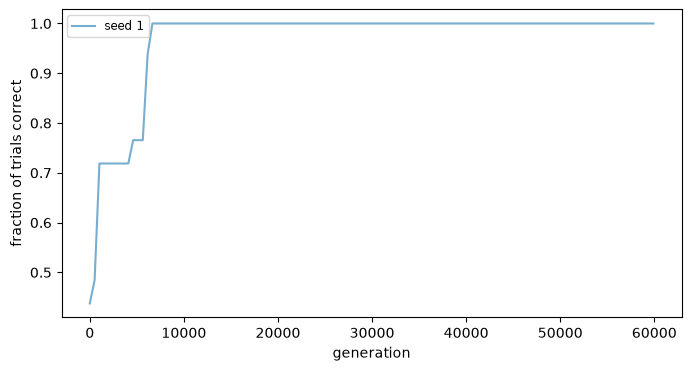

In [2]:
animats = all_animats(TASK)
fig, ax = plt.subplots(figsize=(8, 4))
for seed, g in animats.groupby("seed"):
    ax.plot(g["generation"], g["score"], alpha=0.6, label=f"seed {seed}")
ax.set_xlabel("generation")
ax.set_ylabel("fraction of trials correct")
ax.legend(fontsize="small")
animats.head()

## One animat

In [21]:
seed = 3
generation = list_animats(TASK, seed)["generation"].max()
a = load_animat(TASK, seed, generation)
labels = a["node_labels"]
print(f"seed {a['seed']}, generation {a['generation']}, score {a['score']:.3f}")
pd.DataFrame(a["cm"], index=labels, columns=labels)   # row -> column

seed 3, generation 59904, score 0.969


,S0,S1,M0,M1,H0,H1,H2,H3
S0,0,0,0,0,1,0,1,1
S1,0,0,0,0,0,0,0,0
M0,0,0,0,0,0,0,0,0
M1,0,0,0,0,0,0,0,0
H0,0,0,0,0,0,0,0,1
H1,0,0,0,0,0,0,0,0
H2,0,0,0,0,1,0,1,0
H3,0,0,0,0,1,0,1,0


In [22]:
# states visited during the 128 trials, with their probability of occurrence
pd.DataFrame(a["visited_states"], columns=labels).assign(p=a["visited_probs"]).sort_values("p", ascending=False)

,S0,S1,M0,M1,H0,H1,H2,H3,p
10,0,1,0,0,1,0,0,1,0.221354
2,0,0,0,0,0,0,1,0,0.200955
0,0,0,0,0,0,0,0,0,0.168403
16,1,0,0,0,1,0,0,0,0.107639
1,0,0,0,0,0,0,0,1,0.072483
4,0,0,0,0,1,0,0,0,0.068576
12,1,0,0,0,0,0,0,0,0.021267
6,0,1,0,0,0,0,0,0,0.019965
14,1,0,0,0,0,0,1,0,0.019965
18,1,0,0,0,1,0,1,1,0.013021


## State-weighted measures

The paper averages each causal measure over all brain states the animat experienced during the 128 trials,
weighted by probability of occurrence. `average_over_visited` does that for any function `measure(substrate, state)`.

Many consecutive animats on a line of descent have identical brains; `animats.csv` has a `tpm_hash` column,
so results can be cached by `(tpm_hash, state)` instead of recomputed.

In [23]:
def average_over_visited(animat, measure):
    """Probability-weighted mean of measure(substrate, state) over the animat's visited states."""
    substrate = to_substrate(animat)
    values = np.array([measure(substrate, tuple(int(x) for x in s)) for s in animat["visited_states"]])
    return float(np.sum(values * animat["visited_probs"])), values

In [24]:
# IIT 3.0 Φ of the main complex: the paper's Φ^Max.
# Under IIT 3.0 a result's `.phi` is Φ; in IIT 4.0 results `.phi` is φ_s and `.big_phi` is Φ.
# IIT 3.0 needs pyphi's emd extra: uv pip install -e "$HOME/pyphi[emd]"
import pyphi
pyphi.config.progress_bars = False

def phi_max(substrate, state):
    # complexes() instead of maximal_complex(): when there is no complex, maximal_complex()
    # raises on states pyphi deems unreachable (e.g. hidden nodes at the post-reset 0000
    # if no state leads there); complexes() just returns no complex, i.e. Phi 0
    with pyphi.config.override(**pyphi.iit3):
        found = substrate.complexes(state)
    return float(found[0].phi) if found else 0.0

mean_phi, per_state = average_over_visited(a, phi_max)
mean_phi

0.7978094114583333

## ⟨Φ<sup>Max</sup>⟩ along the line of descent

For every sampled animat (every 512 generations), the probability-weighted mean of a measure over the
states it visited during the 128 trials, as in the paper. Pass one seed or a list: with several seeds the
plot shows the mean across lines of descent, with a ±1 SEM band. Identical brains (common between
consecutive animats, and across seeds early on) are computed once, cached by `(tpm_hash, state)`.

In [28]:
def lod_measure(task, seeds, measure):
    """Weighted mean of measure(substrate, state) over visited states, for every animat on each LOD.

    seeds: one seed or a list. Returns one row per (seed, generation) with score and value.
    """
    seeds = [seeds] if np.isscalar(seeds) else list(seeds)
    cache = {}
    rows = []
    for seed in seeds:
        for row in list_animats(task, seed).itertuples():
            a = load_animat(task, seed, row.generation)
            substrate = None
            value = 0.0
            for s, p in zip(a["visited_states"], a["visited_probs"]):
                key = (row.tpm_hash, tuple(int(x) for x in s))
                if key not in cache:
                    if substrate is None:
                        substrate = to_substrate(a)
                    cache[key] = measure(substrate, key[1])
                value += p * cache[key]
            rows.append({"seed": seed, "generation": row.generation, "score": row.score, "value": value})
        print(f"seed {seed} done ({len(cache)} distinct brain-states computed so far)")
    return pd.DataFrame(rows)


def plot_lod(df, label):
    """Mean of value and fitness across seeds per generation, with ±1 SEM bands if several seeds."""
    stats = df.groupby("generation")[["value", "score"]].agg(["mean", "sem"])
    n_seeds = df["seed"].nunique()
    gen = stats.index
    fig, ax = plt.subplots(figsize=(9, 4))
    fitness_ax = ax.twinx()
    for axis, col, color, ylabel in ((ax, "value", "C0", label),
                                     (fitness_ax, "score", "gray", "fitness (fraction correct)")):
        mean, sem = stats[(col, "mean")], stats[(col, "sem")]
        axis.plot(gen, mean, color=color)
        if n_seeds > 1:
            axis.fill_between(gen, mean - sem, mean + sem, color=color, alpha=0.2, linewidth=0)
        axis.set_ylabel(ylabel, color=color)
    ax.set_xlabel("generation")
    seeds = sorted(df["seed"].unique())
    ax.set_title(f"{TASK}, seed {seeds[0]}" if n_seeds == 1 else f"{TASK}, mean ± SEM over {n_seeds} seeds")
    return fig

seed 1 done (1583 distinct brain-states computed so far)
seed 2 done (2608 distinct brain-states computed so far)
seed 3 done (4905 distinct brain-states computed so far)
seed 4 done (6862 distinct brain-states computed so far)
seed 5 done (8537 distinct brain-states computed so far)
seed 6 done (10989 distinct brain-states computed so far)
seed 7 done (13268 distinct brain-states computed so far)
seed 8 done (14559 distinct brain-states computed so far)
seed 9 done (16363 distinct brain-states computed so far)
seed 10 done (18271 distinct brain-states computed so far)
seed 11 done (20201 distinct brain-states computed so far)
seed 12 done (21363 distinct brain-states computed so far)


seed
1     0.106197
2     0.298731
3     0.797809
4     0.000000
5     0.584323
6     0.284128
7     0.956163
8     0.077221
9     0.405084
10    0.000000
11    0.092999
12    0.000000
Name: max ⟨Φ^Max⟩ on LOD, dtype: float64

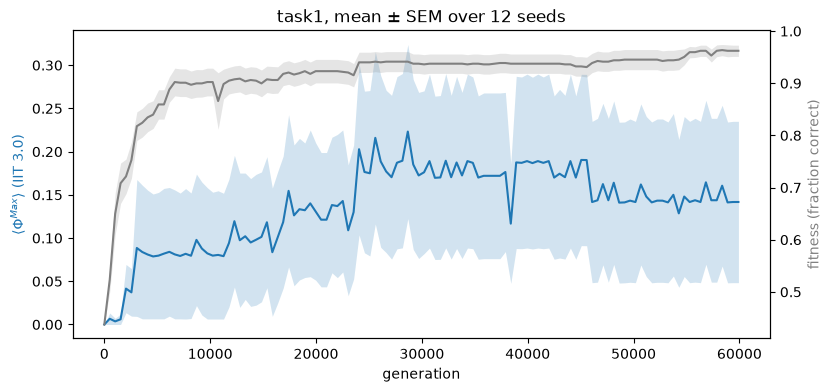

In [29]:
seeds = list_seeds(TASK)          # or one seed, e.g. 3, or a list, e.g. [1, 4, 7]
phi_lod = lod_measure(TASK, seeds, phi_max)
plot_lod(phi_lod, "⟨Φ$^{Max}$⟩ (IIT 3.0)")
phi_lod.groupby("seed")["value"].max().rename("max ⟨Φ^Max⟩ on LOD")